In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
print(tf.__version__)

2.3.0


In [46]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

3670


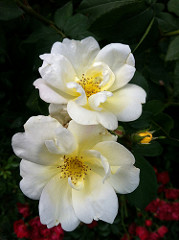

In [47]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))

In [48]:
batch_size = 32
img_height = 20
img_width =20

In [49]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [50]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [51]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [52]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)

In [53]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 0.9368631


In [54]:
num_classes = 5

model = Sequential([
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(4, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(8, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(num_classes)
])

In [55]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [56]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling_6 (Rescaling)      (None, 20, 20, 3)         0         
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 20, 20, 4)         112       
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 10, 10, 4)         0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 10, 10, 8)         296       
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 5, 5, 8)           0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 200)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 5)                

In [60]:
epochs=3
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/3
92/92 [==============================] - 1s 11ms/step - loss: 1.2124 - accuracy: 0.4775 - val_loss: 1.2298 - val_accuracy: 0.4905
Epoch 2/3
92/92 [==============================] - 1s 10ms/step - loss: 1.1843 - accuracy: 0.5017 - val_loss: 1.1999 - val_accuracy: 0.4986
Epoch 3/3
92/92 [==============================] - 1s 10ms/step - loss: 1.1602 - accuracy: 0.5163 - val_loss: 1.1902 - val_accuracy: 0.5218


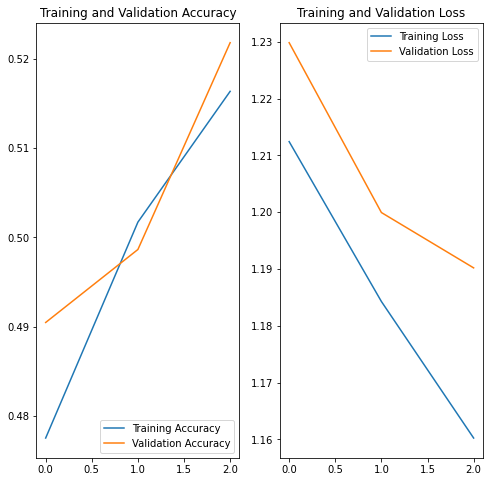

In [61]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [64]:
import time
sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = keras.preprocessing.image.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
start_time=time.time()
predictions = model.predict(img_array)
print(time.time()-start_time)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

0.06602120399475098
This image most likely belongs to tulips with a 59.87 percent confidence.


In [65]:
model.save('con2_20_test.h5')

In [3]:
new_model = tf.keras.models.load_model('con2_300.h5')

# Show the model architecture
new_model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling_4 (Rescaling)      (None, 300, 300, 3)       0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 300, 300, 64)      1792      
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 150, 150, 64)      0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 150, 150, 128)     73856     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 75, 75, 128)       0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 720000)            0         
_________________________________________________________________
dense_2 (Dense)              (None, 5)                